# Solar Energy Generation - Data Pre-processing and EDA

**Install requirements**

In [ ]:

%pip install pandas==1.5.3 
%pip install requests==2.31
%pip install plotly==5.24.1
%pip install seaborn==0.13.2
%pip install geopy==2.3.0 # for geographical data
%pip install kaleido==0.2.1 # for plotly image processing/export
%pip install geopandas==0.13.2
%pip install fiona==1.8.20 # newer versions do not work!
%pip install scipy==1.8.0
%pip install scikit-learn==1.2.2
%pip install imbalanced-learn==0.12

**Importing necessary libraries and the data**

In [41]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
import matplotlib.pyplot as plt

path1 = "~/dec24_bds_solar_energy/data/raw/Solar_Footprints_V2_7811899327930675815.csv"
path2 = "~/dec24_bds_solar_energy/data/raw/Population-Density By County.csv"

dfs = pd.read_csv(path1, index_col="OBJECTID") # data frame for solar data
dfp = pd.read_csv(path2) # data frame for US population data

#df = pd.read_csv("Solar_Footprints_V2_7811899327930675815.csv", index_col="OBJECTID") # the raw data should not be in ./notebooks
#dp = pd.read_csv("Population-Density By County.csv") # the raw data should not be in ./notebooks

# Filter rows with "California" in the "GEO.display-label" column
dfp = dfp[dfp["GEO.display-label"].str.contains("California", na=False)]

**First overview over the data and first cleanup**

In [42]:
print("Solar DataFrame Shape:", dfs.shape)
display("Solar DataFrame:", dfs.head())
print("Population DataFrame Shape:", dfp.shape)
display("Population DataFrame:", dfp.head())

Solar DataFrame Shape: (5397, 20)


'Solar DataFrame:'

,County,Acres,Install Type,Urban or Rural,Combined Class,Distance to Substation (Miles) GTET 100 Max Voltage,Percentile (GTET 100 Max Voltage),Substation Name GTET 100 Max Voltage,HIFLD ID (GTET 100 Max Voltage),Distance to Substation (Miles) GTET 200 Max Voltage,Percentile (GTET 200 Max Voltage),Substation Name GTET 200 Max Voltage,HIFLD ID (GTET 200 Max Voltage),Distance to Substation (Miles) CAISO,Percentile (CAISO),Substation CASIO Name,HIFLD ID (CAISO),Solar Technoeconomic Intersection,Shape__Area,Shape__Length
OBJECTID,,,,,,,,,,,,,,,,,,,,
1,Alameda County,1.67,Rooftop,Urban,Rooftop - Urban,0.16,0 to 25th,Dixon Landing,309200.00,2.27,0 to 25th,Los Esteros,310258.00,2.27,0 to 25th,Los Esteros,310258.00,Within,6768.95,365.80
2,Alameda County,1.90,Rooftop,Urban,Rooftop - Urban,0.23,0 to 25th,Dixon Landing,309200.00,2.39,0 to 25th,Los Esteros,310258.00,2.39,0 to 25th,Los Esteros,310258.00,Within,7677.23,366.91
3,Alameda County,1.28,Rooftop,Urban,Rooftop - Urban,0.43,0 to 25th,Dixon Landing,309200.00,2.54,0 to 25th,Los Esteros,310258.00,2.54,0 to 25th,Los Esteros,310258.00,Within,5162.94,290.58
4,Alameda County,1.42,Rooftop,Urban,Rooftop - Urban,0.49,0 to 25th,Dixon Landing,309200.00,2.63,0 to 25th,Los Esteros,310258.00,2.63,0 to 25th,Los Esteros,310258.00,Within,5763.91,344.71
5,Alameda County,0.98,Rooftop,Urban,Rooftop - Urban,0.80,0 to 25th,Dixon Landing,309200.00,2.73,0 to 25th,Los Esteros,310258.00,2.73,25th to 50th,Los Esteros,310258.00,Within,3983.86,283.97


Population DataFrame Shape: (58, 7)


'Population DataFrame:'

,GEO.id,GEO.id2,GEO.display-label,GCT_STUB.target-geo-id,GCT_STUB.target-geo-id2,GCT_STUB.display-label,Density per square mile of land area
186,0400000US06,6,California,0500000US06001,6001,Alameda County,2043.60
187,0400000US06,6,California,0500000US06003,6003,Alpine County,1.60
188,0400000US06,6,California,0500000US06005,6005,Amador County,64.10
189,0400000US06,6,California,0500000US06007,6007,Butte County,134.40
190,0400000US06,6,California,0500000US06009,6009,Calaveras County,44.70


In [43]:
# Checking the missing values of both DataFrames
def print_missing_info(df, df_name):
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / df.shape[0]) * 100
    print(f"\nMissing Values in {df_name}:\n{missing_count}")
    print(f"\nMissing Values (Percentage) in {df_name}:\n{missing_percentage}")

print_missing_info(dfs, "Solar Data")
print_missing_info(dfp, "Population Data")

# There are very few missing values in the solar dataframe while there are no missing values in the population dataframe.


Missing Values in Solar Data:
County                                                   0
Acres                                                    0
Install Type                                             0
Urban or Rural                                           0
Combined Class                                           0
Distance to Substation (Miles) GTET 100 Max Voltage      0
Percentile (GTET 100 Max Voltage)                        0
Substation Name GTET 100 Max Voltage                     0
HIFLD ID (GTET 100 Max Voltage)                        142
Distance to Substation (Miles) GTET 200 Max Voltage      0
Percentile (GTET 200 Max Voltage)                        0
Substation Name GTET 200 Max Voltage                     0
HIFLD ID (GTET 200 Max Voltage)                        232
Distance to Substation (Miles) CAISO                     0
Percentile (CAISO)                                       0
Substation CASIO Name                                   10
HIFLD ID (CAISO)         

In [44]:
# Multiple columns have very long names in dfs, which can be shortened

abbrev_dict = {"Distance to Substation (Miles) GTET 100 Max Voltage" : "Distance to GTET 100", # "GTET" likely stands for "Grid-Connected Transformer Equipment Terminal"           
               "Percentile (GTET 100 Max Voltage)" : "Percentile (GTET 100)",
               "Substation Name GTET 100 Max Voltage" : "Substation Name GTET 100",
               "Distance to Substation (Miles) GTET 200 Max Voltage" : "Distance to GTET 200",
               "Percentile (GTET 200 Max Voltage)" : "Percentile (GTET 200)",
               "Substation Name GTET 200 Max Voltage" : "Substation Name GTET 200",
               "Distance to Substation (Miles) CAISO" : "Distance to CAISO substation"}

dfs.rename(abbrev_dict, axis=1, inplace = True)

# Multiple columns can be dropped due to their lack of informative value. 
# This applies to ID columns, the substation name columns, the Shape__Length and the "Shape Area" column, which represents the same information as the "Acres" column but in 
# square meters instead of square miles. And finally, "Combined Class" is dropped because there is no added information in this column (it only concatenates two other columns),
# although sometimes it can be beneficial to use such combined features when they reveal interactions between features that might be valuable and not seen before.
dfs.drop(["HIFLD ID (GTET 100 Max Voltage)", "HIFLD ID (GTET 200 Max Voltage)", "HIFLD ID (CAISO)", "Substation Name GTET 100", "Substation Name GTET 200", 
         "Substation CASIO Name", "Shape__Area","Shape__Length", "Combined Class"], axis = 1, inplace = True)

print(dfs.shape)
dfs.head()

(5397, 11)


,County,Acres,Install Type,Urban or Rural,Distance to GTET 100,Percentile (GTET 100),Distance to GTET 200,Percentile (GTET 200),Distance to CAISO substation,Percentile (CAISO),Solar Technoeconomic Intersection
OBJECTID,,,,,,,,,,,
1,Alameda County,1.67,Rooftop,Urban,0.16,0 to 25th,2.27,0 to 25th,2.27,0 to 25th,Within
2,Alameda County,1.90,Rooftop,Urban,0.23,0 to 25th,2.39,0 to 25th,2.39,0 to 25th,Within
3,Alameda County,1.28,Rooftop,Urban,0.43,0 to 25th,2.54,0 to 25th,2.54,0 to 25th,Within
4,Alameda County,1.42,Rooftop,Urban,0.49,0 to 25th,2.63,0 to 25th,2.63,0 to 25th,Within
5,Alameda County,0.98,Rooftop,Urban,0.80,0 to 25th,2.73,0 to 25th,2.73,25th to 50th,Within


**Adding features and combining the data frames**

In [45]:
# Constructing data frame for longitudes and latitudes of the counties
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="geoapi")
california_counties=dfs.County.unique()
latitude = []
longitude = []

for county in california_counties:
    location = geolocator.geocode(f"{county}, California")
    latitude.append(location.latitude)
    longitude.append(location.longitude)

dgeo=pd.DataFrame({"County":dfs.County.unique(),"Latitude":latitude,"Longitude":longitude})

dgeo.head()

,County,Latitude,Longitude
0,Alameda County,37.61,-121.90
1,Amador County,38.45,-120.59
2,Butte County,39.65,-121.59
3,Calaveras County,38.26,-120.50
4,Colusa County,39.15,-122.22


In [46]:
# Population data frame processing
#dfp=dfp[(dfp["GEO.display-label"]=="California")] # XXX not needed anymore because it is done at the beginning before checking the data
dfp=dfp[["GCT_STUB.display-label","Density per square mile of land area"]]
dfp.rename(columns={"GCT_STUB.display-label":"County","Density per square mile of land area":"Population Density"},inplace=True)

dfp.head()

,County,Population Density
186,Alameda County,2043.60
187,Alpine County,1.60
188,Amador County,64.10
189,Butte County,134.40
190,Calaveras County,44.70


In [47]:
dfs_temp=pd.merge(dfs, dgeo, on="County", how="left").set_index(dfs.index) # XXX You typically use an outer join when you want to ensure that you retain all the data from both DataFrames
df=pd.merge(dfs_temp, dfp, on="County", how="left")#.set_index(dfs_temp.index)
#df=dfs.dropna() # not needed when "left" join is used
df=df.set_index(dfs_temp.index)

print(df.shape)
df.head()

(5397, 14)


,County,Acres,Install Type,Urban or Rural,Distance to GTET 100,Percentile (GTET 100),Distance to GTET 200,Percentile (GTET 200),Distance to CAISO substation,Percentile (CAISO),Solar Technoeconomic Intersection,Latitude,Longitude,Population Density
OBJECTID,,,,,,,,,,,,,,
1,Alameda County,1.67,Rooftop,Urban,0.16,0 to 25th,2.27,0 to 25th,2.27,0 to 25th,Within,37.61,-121.90,2043.60
2,Alameda County,1.90,Rooftop,Urban,0.23,0 to 25th,2.39,0 to 25th,2.39,0 to 25th,Within,37.61,-121.90,2043.60
3,Alameda County,1.28,Rooftop,Urban,0.43,0 to 25th,2.54,0 to 25th,2.54,0 to 25th,Within,37.61,-121.90,2043.60
4,Alameda County,1.42,Rooftop,Urban,0.49,0 to 25th,2.63,0 to 25th,2.63,0 to 25th,Within,37.61,-121.90,2043.60
5,Alameda County,0.98,Rooftop,Urban,0.80,0 to 25th,2.73,0 to 25th,2.73,25th to 50th,Within,37.61,-121.90,2043.60


**Exploratory Data Analysis**

*1. Basic overview*

In [48]:
# Basic Information about the full data frame
print(df.info(), "\n")  # Check for missing values and data types

print("There is", df.duplicated().sum() ,"duplicated data in the dataset.")

print("\nSummary Statistics:\n")
df.describe() # Summary statistics for numerical features

# The data types seem correct and we have no missing values anymore. But the dataset consists of data with outliers.

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5397 entries, 1 to 5397
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   County                             5397 non-null   object 
 1   Acres                              5397 non-null   float64
 2   Install Type                       5397 non-null   object 
 3   Urban or Rural                     5397 non-null   object 
 4   Distance to GTET 100               5397 non-null   float64
 5   Percentile (GTET 100)              5397 non-null   object 
 6   Distance to GTET 200               5397 non-null   float64
 7   Percentile (GTET 200)              5397 non-null   object 
 8   Distance to CAISO substation       5397 non-null   float64
 9   Percentile (CAISO)                 5397 non-null   object 
 10  Solar Technoeconomic Intersection  5397 non-null   object 
 11  Latitude                           5397 non-null   float

,Acres,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Latitude,Longitude,Population Density
count,5397.00,5397.00,5397.00,5397.00,5397.00,5397.00,5397.00
mean,27.84,4.88,9.01,6.49,36.03,-119.47,887.78
std,185.73,5.60,8.96,5.26,1.86,2.02,1261.60
min,0.00,0.00,0.00,0.00,32.96,-123.90,1.80
25%,0.94,1.36,3.12,2.66,34.32,-121.30,103.30
50%,2.10,2.77,6.14,5.06,36.22,-119.77,307.10
75%,4.78,6.18,12.00,8.78,37.55,-118.21,1465.20
max,7438.60,55.75,102.22,60.38,40.80,-115.36,17179.20


*2. Boxplot: Distance of solar installations from substations*

In [49]:
# Create a boxplot matrix

def plot_boxplot_matrix():

    # Reshape the DataFrame from wide to long format in order to plot it clean
    df_with_index = df.reset_index()
    #print(df_with_index)
    df_long = df_with_index.melt(
        id_vars=["OBJECTID", "Install Type"],  # Keep "Install Type" as the identifier
        value_vars=[
            "Distance to GTET 100",
            "Distance to GTET 200",
            "Distance to CAISO substation"
        ],  # Columns to melt
        var_name="Substation Type",  # New column for substation types
        value_name="Distance"  # New column for distance values
    )

    #df_long

    fig = px.box(
        df_long,
        x="Install Type",  # X-axis: Install Type
        y="Distance",  # Y-axis: Distance
        color="Substation Type",  # Color by substation type
        facet_col="Substation Type",  # Create subplots for each substation type
        title="Boxplot: Distance to Substations by Install Type and Substation Type",
        labels={"Distance": "Distance to Substation (Miles)", "Install Type": "Install Type"},  # Customize axis labels
        width=1200,
        height=700,
        facet_col_spacing=0.05  # Reduce spacing between subplots
    )

    # Update layout for better readability
    fig.update_layout(
        xaxis_title="Install Type",  # X-axis label
        yaxis_title="Distance to Substation (Miles)",  # Y-axis label
        showlegend=False,  # Show legend to differentiate substation types
        font=dict(size=12),  # Adjust font size for better readability
        boxmode="group",  # Group boxplots by install type
        #margin=dict(l=50, r=50, t=80, b=50),  # Adjust margins to prevent overlap

    )

    # Adjust facet column spacing and titles
    fig.update_xaxes(matches=None, showticklabels=True)  # Ensure x-axis labels are shown for each subplot
    fig.update_yaxes(matches=None, showticklabels=True)  # Ensure y-axis labels are shown for each subplot
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # Clean up facet titles

    # Show the figure
    fig.show()
   
    # Save the figure as a PNG file (ONCE!)
    pio.write_json(fig, "/home/ubuntu/dec24_bds_solar_energy/data/processed/Boxplotmatrix.json")
    fig.write_image("/home/ubuntu/dec24_bds_solar_energy/reports/figures/Boxplotmatrix.png")

print("Boxplot matrix")
plot_boxplot_matrix()

Boxplot matrix


*3. Geographical distribution of solar panels*

In [50]:
# California Map initiator / Geolocator
import geopandas as gpd
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
states = gpd.read_file(url)
california = states[states["name"] == "California"]

In [51]:
# Geographical plot of Total solar installations per coounty
total_solar=df[["County" ,"Urban or Rural","Latitude","Longitude"]].value_counts().reset_index()
#total_solar.head()
total_solar.columns=["County" ,"Urban or Rural","Latitude","Longitude","frequency"]
total_solar_rural=total_solar[total_solar["Urban or Rural"]!="Urban"]
total_solar_urban=total_solar[total_solar["Urban or Rural"]!="Rural"]
#total_solar_rural.head()

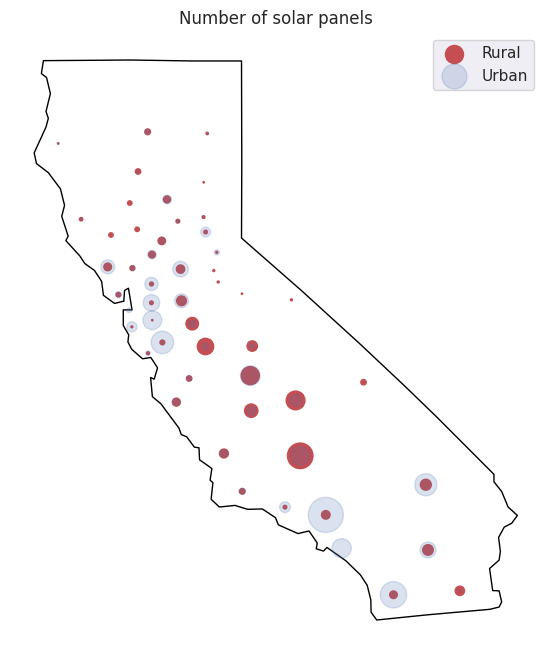

In [52]:
# Plotting
california.plot(edgecolor="black", facecolor="none", figsize=(8, 8))
plt.title("Number of solar panels")
plt.scatter(total_solar_rural.Longitude,total_solar_rural.Latitude,s=total_solar_rural.frequency,c="r",label="Rural")
plt.scatter(total_solar_urban.Longitude,total_solar_urban.Latitude,s=total_solar_urban.frequency,c="b",label="Urban",alpha=0.2)
plt.axis("off")
plt.legend();

*4. Solar panels number versus population distribution*

In [53]:
solar_area=df.groupby("County")["Acres"].sum()
solar_area_df=pd.merge(solar_area,df.drop("Acres",axis=1),on=["County"],how="outer")
#solar_area_df.info()

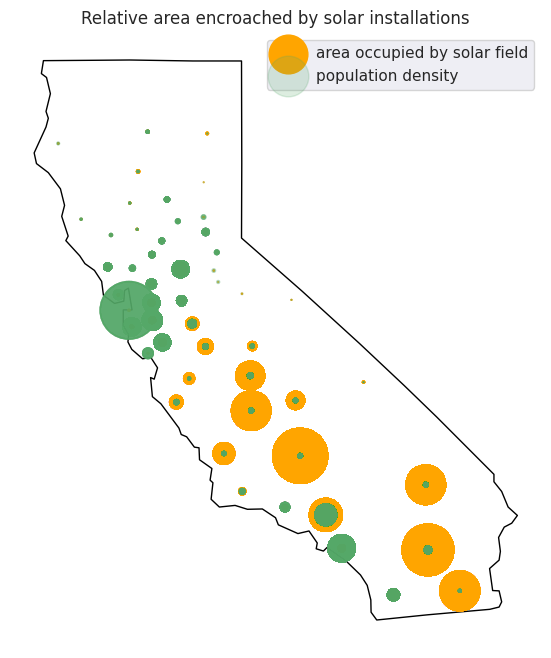

In [54]:
# Plotting
california.plot(edgecolor="black", facecolor="none", figsize=(8, 8))
plt.title("Relative area encroached by solar installations")
plt.scatter(solar_area_df.Longitude,solar_area_df.Latitude,s=solar_area_df.Acres/20,c="orange",label="area occupied by solar field")
plt.scatter(solar_area_df.Longitude,solar_area_df.Latitude,s=solar_area_df["Population Density"]/10,c="g",label="population density",alpha=0.2)
plt.legend()
plt.axis("off");

*5. Area distribution by Urban/Rural*

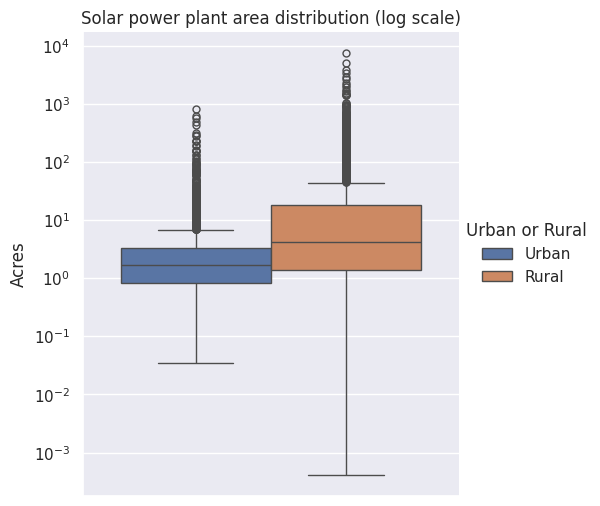

In [55]:
# Distribution of acres in log scale
sns.set() # to change theme
sns.catplot(data=df, y="Acres", kind="box", hue="Urban or Rural")
plt.title("Solar power plant area distribution (log scale)")
plt.yscale("log")
plt.show();

*6. Area distribution by Urban/Rural*

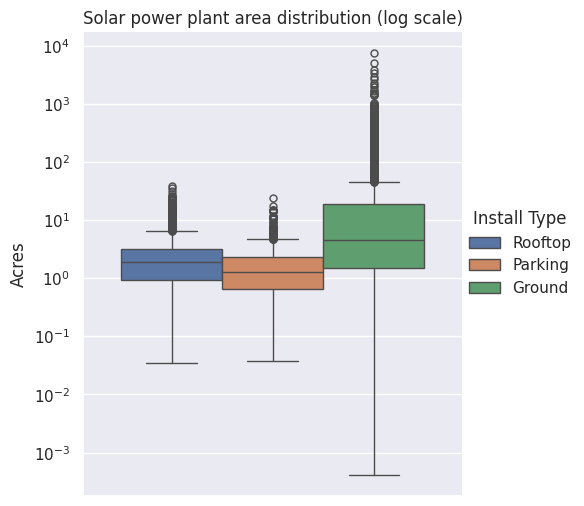

In [56]:
# Distribution of acres in log scale
sns.set() # to change theme
sns.catplot(data=df, y="Acres", kind="box", hue="Install Type")
plt.title("Solar power plant area distribution (log scale)")
plt.yscale("log")
plt.show();

*7. Distribution of install types in urban and rural areas*

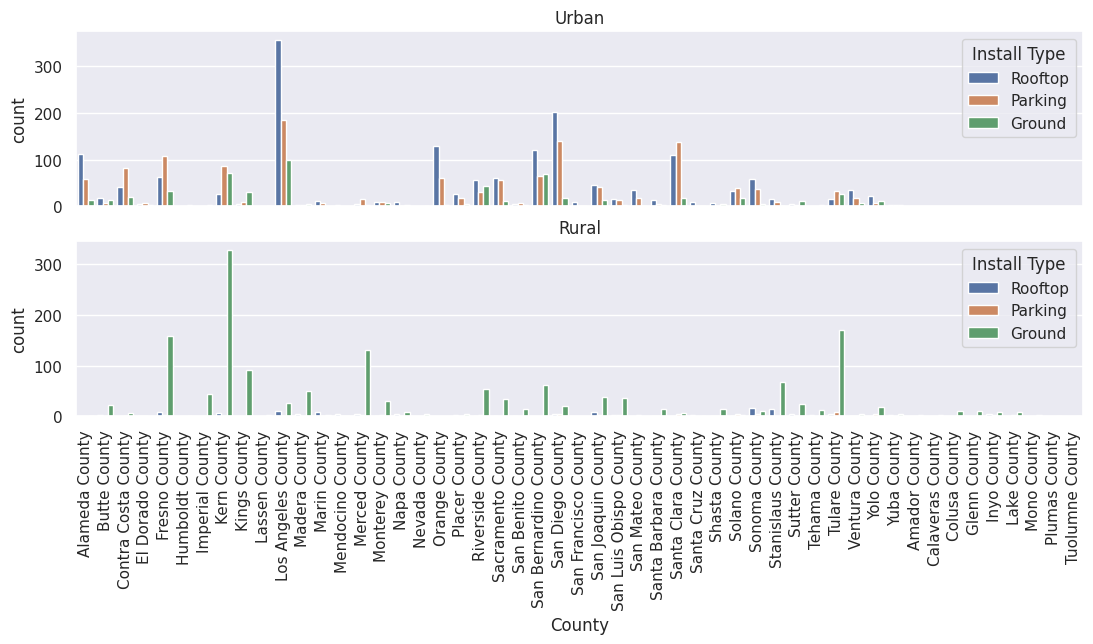

In [57]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(13, 5))
sns.countplot(x=df[(df["Urban or Rural"]=="Urban")]["County"], hue="Install Type",data=df,ax=axes[0])
axes[0].set_title("Urban")
sns.countplot(x=df[(df["Urban or Rural"]=="Rural")]["County"], hue="Install Type",data=df,ax=axes[1])
axes[1].set_title("Rural")
plt.xticks(rotation=90);

**Statistical tests**

In [58]:
# On basis of the previous findings some relationships could be further examined by statstical tests:
# 1. Relationship between Population Density (continous, non-normal distributed variable) and the target variable (binary variable) -> Point-Biserial Correlation
# 2. Relationship between Distance GTET 200 (continous, non-normal distributed variable) and the target variable (binary variable) -> Point-Biserial Correlation

# Since they were not included in the correlation analysis (because they are categorical features), additional relationships could be explored:
# 3. Relationship between Install Type (categorical variable) and the target variable (binary variable) -> Chi-Square Test of Independence
# 4. Relationship between "Urban and Rural" (categorical variable) and the target variable (binary variable) -> Chi-Square Test of Independence

import scipy.stats as stats
from scipy.stats import pointbiserialr

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------#

# 1. Point-Biserial Correlation

# Check the normality of "Population Density"

# Shapiro-Wilk test for normality
shapiro_pop_density = stats.shapiro(df["Population Density"])
print(f"Shapiro-Wilk test for Population Density: Statistic={shapiro_pop_density.statistic}, p-value={shapiro_pop_density.pvalue}")

# If the p-value < 0.05, the data is not normally distributed
if shapiro_pop_density.pvalue < 0.05:
    print("Population Density is NOT normally distributed (reject the null hypothesis). Proceeding with non-parametric methods.")
else:
    print("Population Density is normally distributed (fail to reject the null hypothesis).")

# Perform Point-Biserial Correlation between "Population Density" and the binary target variable "Solar Technoeconomic Intersection"
corr_pop_density, p_value = stats.pointbiserialr(df["Population Density"], df["Solar Technoeconomic Intersection"].apply(lambda x: 1 if x == "Within" else 0))

# Print the results
print(f"\nPoint-Biserial Correlation between Population Density and Solar Technoeconomic Intersection: {corr_pop_density}")
print(f"p-value: {p_value}")

# Interpret the correlation result
if p_value < 0.05:
    print("There is a significant relationship between Population Density and Solar Technoeconomic Intersection.", "\n\n")
else:
    print("There is no significant relationship between Population Density and Solar Technoeconomic Intersection.", "\n\n")

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------#

# 2. Point-Biserial Correlation

# Check the normality of "Distance to GTET 200"

# Shapiro-Wilk test for normality
shapiro_Distance_GTET_200 = stats.shapiro(df["Distance to GTET 200"])
print(f"Shapiro-Wilk test for Distance to GTET 200: Statistic={shapiro_Distance_GTET_200.statistic}, p-value={shapiro_Distance_GTET_200.pvalue}")

# If the p-value < 0.05, the data is not normally distributed
if shapiro_Distance_GTET_200.pvalue < 0.05:
    print("Distance to GTET 200 is NOT normally distributed (reject the null hypothesis). Proceeding with non-parametric methods.")
else:
    print("Distance to GTET 200 is normally distributed (fail to reject the null hypothesis).")

# Perform Point-Biserial Correlation between "Distance to GTET 200" and the binary target variable "Solar Technoeconomic Intersection"
corr_Distance_GTET_200, p_value = stats.pointbiserialr(df["Distance to GTET 200"], df["Solar Technoeconomic Intersection"].apply(lambda x: 1 if x == "Within" else 0))

# Print the results
print(f"\nPoint-Biserial Correlation between Distance to GTET 200 and Solar Technoeconomic Intersection: {corr_Distance_GTET_200}")
print(f"p-value: {p_value}")

# Interpret the correlation result
if p_value < 0.05:
    print("There is a significant relationship between Distance to GTET 200 and Solar Technoeconomic Intersection.", "\n\n")
else:
    print("There is no significant relationship between Distance to GTET 200 and Solar Technoeconomic Intersection.", "\n\n")

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------#

# 3. Chi-Square Test for categorical variable "Install Type"
from scipy.stats import chi2_contingency

# Create contingency table and perform the Chi-Square test
contingency_table = pd.crosstab(df["Install Type"], df["Solar Technoeconomic Intersection"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square statistic between 'Install Type' and 'Solar Technoeconomic Intersection': {chi2}, p-value: {p}", "\n\n")

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------#

# 4. Chi-Square Test for categorical variable "Urban or Rural"

# Create contingency table and perform the Chi-Square test
contingency_table = pd.crosstab(df["Urban or Rural"], df["Solar Technoeconomic Intersection"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square statistic between 'Urban or Rural' and 'Solar Technoeconomic Intersection': {chi2}, p-value: {p}", "\n\n")

Shapiro-Wilk test for Population Density: Statistic=0.5980127453804016, p-value=0.0
Population Density is NOT normally distributed (reject the null hypothesis). Proceeding with non-parametric methods.

Point-Biserial Correlation between Population Density and Solar Technoeconomic Intersection: 0.2747224750762423
p-value: 4.622527458113252e-94
There is a significant relationship between Population Density and Solar Technoeconomic Intersection. 


Shapiro-Wilk test for Distance to GTET 200: Statistic=0.7807221412658691, p-value=0.0
Distance to GTET 200 is NOT normally distributed (reject the null hypothesis). Proceeding with non-parametric methods.

Point-Biserial Correlation between Distance to GTET 200 and Solar Technoeconomic Intersection: -0.26706179695122434
p-value: 8.40482629222274e-89
There is a significant relationship between Distance to GTET 200 and Solar Technoeconomic Intersection. 


Chi-Square statistic between 'Install Type' and 'Solar Technoeconomic Intersection': 2475.1

/home/ubuntu/dec24_bds_solar_energy/solar_venv/lib/python3.8/site-packages/scipy/stats/_morestats.py:1761: UserWarning:

p-value may not be accurate for N > 5000.



**Pre-Model preparation (Split, Encoding, Re-Sampling, Scaling)**

In [59]:
# Values of categorical variables:
print("Install Type: ",df["Install Type"].unique())
print("Urban or Rural: ",df["Urban or Rural"].unique())
print("Percentile (GTET 100): ",df["Percentile (GTET 100)"].unique())
print("Percentile (GTET 200): ",df["Percentile (GTET 200)"].unique())
print("Percentile (CAISO): ",df["Percentile (CAISO)"].unique())
print("Solar Technoeconomic Intersection: ",df["Solar Technoeconomic Intersection"].unique())

Install Type:  ['Rooftop' 'Parking' 'Ground']
Urban or Rural:  ['Urban' 'Rural']
Percentile (GTET 100):  ['0 to 25th' '25th to 50th' '50th to 75th' '75th to 100th']
Percentile (GTET 200):  ['0 to 25th' '25th to 50th' '50th to 75th' '75th to 100th']
Percentile (CAISO):  ['0 to 25th' '25th to 50th' '50th to 75th' '75th to 100th']
Solar Technoeconomic Intersection:  ['Within' 'Outside']


*Encoding*

In [60]:
# XXX I think that this section should be directly the first after the train-test-split and before the heatmap. 

# Variables with Percentile will be ordinally encoded
from sklearn.preprocessing import OrdinalEncoder

df_enc=df

encoder_ordinal = OrdinalEncoder(categories=[["0 to 25th","25th to 50th","50th to 75th","75th to 100th"]])

df_enc["percentile_GTET100"] = pd.DataFrame(encoder_ordinal.fit_transform(df[["Percentile (GTET 100)"]])).set_index(df_enc.index)
df_enc["percentile_GTET200"] = pd.DataFrame(encoder_ordinal.fit_transform(df[["Percentile (GTET 200)"]])).set_index(df_enc.index)
df_enc["percentile_CAISO"] = pd.DataFrame(encoder_ordinal.fit_transform(df[["Percentile (CAISO)"]])).set_index(df_enc.index)

# get dummies for the variable "install type" (XXX Avoiding multicollinearity: If we do not drop one category (e.g the first one by: drop_first=True), it will introduce a dummy variable 
# trap, meaning the created features will be highly correlated (or linearly dependent) with each other. This can lead to issues with model training, especially when using linear models
# like logistic regression. In this case the Install Type "Ground" is dropped and the remaining categories are used as binary (0/1) columns. This ensures also that there is no redundant
# information in the dataset.)
df_enc = pd.concat([df_enc, pd.get_dummies(df_enc["Install Type"], dtype=int, drop_first=True)], axis=1)

# Variables "Urban or Rural" and "Solar technoeconomic Intersection" are simply converted to binary
df_enc["Urban or Rural"]=df_enc["Urban or Rural"].map({"Urban":0,"Rural":1}).astype(int)
df_enc["Solar Technoeconomic Intersection"]=df_enc["Solar Technoeconomic Intersection"].map({"Within":1,"Outside":0}).astype(int)

# We also drop "County" variable
df_enc=df_enc.drop(["Percentile (GTET 100)","Percentile (GTET 200)","Percentile (CAISO)","Install Type","County"],axis=1)

# Reordering the columns
df_enc=pd.concat([df_enc.drop("Solar Technoeconomic Intersection",axis=1),df_enc["Solar Technoeconomic Intersection"]],axis=1)

df_enc.tail()

,Acres,Urban or Rural,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Latitude,Longitude,Population Density,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop,Solar Technoeconomic Intersection
OBJECTID,,,,,,,,,,,,,,
5393,8.03,0,12.65,70.97,12.65,40.60,-123.90,37.70,3.00,3.00,3.00,0,0,1
5394,45.85,1,2.56,2.61,5.05,33.03,-115.36,41.80,1.00,0.00,1.00,0,0,0
5395,1.31,1,6.15,7.51,34.86,33.72,-116.04,303.80,2.00,2.00,3.00,1,0,0
5396,0.60,1,7.13,7.13,38.16,33.72,-116.04,303.80,3.00,2.00,3.00,1,0,1
5397,5.74,1,3.97,12.94,3.97,35.31,-118.75,103.30,2.00,3.00,1.00,0,0,0


*Train-test-split*

In [61]:
# We are performing the train-test-split before other model pre-processing steps in order to prevent data leakage and overfitting

from sklearn.model_selection import train_test_split

X=df_enc.drop("Solar Technoeconomic Intersection",axis=1)
y=df_enc["Solar Technoeconomic Intersection"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# After the encoding the dataset consists only of numerical columns
print(X_train.dtypes)

Acres                           float64
Urban or Rural                    int64
Distance to GTET 100            float64
Distance to GTET 200            float64
Distance to CAISO substation    float64
Latitude                        float64
Longitude                       float64
Population Density              float64
percentile_GTET100              float64
percentile_GTET200              float64
percentile_CAISO                float64
Parking                           int64
Rooftop                           int64
dtype: object


*Correlation analysis*

In [62]:
# Create correlation Heatmap (for numerical features of the training data)

def plot_correlation_heatmap(dataframe):

    # Calculate the correlation coefficients (we do only have numeric columns now after the encoding)
    corr = dataframe.corr(numeric_only=True)

    # Use mask to cover redundant values
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    corr_masked = corr.mask(mask)
    #print(mask, corr.values, corr_masked.values)
    
    # Flip the correlation matrix and the mask vertically
    corr_flipped = np.flip(corr_masked.values, axis=0)
    mask_flipped = np.flip(mask, axis=0)

    # Create text for the heatmap tiles
    text_values = np.where(mask_flipped, "", np.around(corr_flipped, 2))  # Set text to empty string for masked tiles

    #print(text_values) # this will be flipped in go.Heatmap() automatically

    fig = go.Figure(data=go.Heatmap(
        x=corr.columns, 
        y=corr.columns[::-1],
        z=np.flip(corr_masked.values, axis=0),  # Flip the correlation matrix vertically  # Apply mask to hide upper triangle
        colorscale="RdBu", zmin=-1, zmax=1,
        colorbar=dict(title="Correlation Coefficient"),
        text = text_values,
        texttemplate="%{text:.2f}",  # Format text to 2 decimal places
        hovertemplate=(
            "<b>X</b>: %{x}<br>"  # Feature name on the x-axis
            "<b>Y</b>: %{y}<br>"  # Feature name on the y-axis
            "<b>Correlation</b>: %{z:.2f}<br>"  # Correlation value (formatted to 2 decimal places)
            "<extra></extra>"  # Remove the extra hover info
        )
    )
    )
    
    fig.update_layout(
        title="Correlation Heatmap",
        height=700, width=1100,
        xaxis=dict(title="Features", showgrid=False),
        yaxis=dict(title="Features", showgrid=False)    
    )

    fig.show()
    
    # Save the figure as a PNG file (ONCE!)
    pio.write_json(fig, "/home/ubuntu/dec24_bds_solar_energy/data/processed/Heatmap.json")
    fig.write_image("/home/ubuntu/dec24_bds_solar_energy/reports/figures/Heatmap.png")
    
train_data = X_train.copy()  # Make a copy of X_train
train_data['Solar Technoeconomic Intersection'] = y_train  # Add target variable
print("Correlation heatmap for all numerical features")
plot_correlation_heatmap(train_data)


Correlation heatmap for all numerical features


In [63]:
# Since longitude and latitude have very little correlation with the target variable, we will drop them from the training set
X_train = X_train.drop(["Longitude","Latitude"], axis=1)

# Now X_train and X_test differ in regards of the number of columns but this will be managed later through a pipeline during the scaling step.
display("X_train:", X_train.head())
display("X_test:", X_test.head())

'X_train:'

,Acres,Urban or Rural,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Population Density,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
OBJECTID,,,,,,,,,,,
3580,1.90,0,4.39,4.39,3.95,735.80,2.00,1.00,1.00,0,1
3197,5.32,0,2.63,9.89,2.65,101.50,1.00,2.00,0.00,0,0
3559,1.53,0,2.37,2.37,2.48,735.80,1.00,0.00,0.00,1,0
1686,5.78,0,0.72,0.72,5.55,2419.60,0.00,0.00,2.00,0,1
3809,0.32,0,0.71,3.00,4.96,492.60,0.00,0.00,1.00,1,0


'X_test:'

,Acres,Urban or Rural,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Latitude,Longitude,Population Density,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
OBJECTID,,,,,,,,,,,,,
723,2.03,0,1.17,1.17,1.40,36.67,-119.82,156.20,0.00,0.00,0.00,1,0
4191,0.85,0,1.78,5.53,2.18,37.23,-121.68,1381.00,1.00,1.00,0.00,1,0
85,1.11,0,2.01,2.12,15.72,37.61,-121.90,2043.60,1.00,0.00,3.00,1,0
3693,0.91,0,2.57,2.57,2.57,32.96,-116.77,735.80,1.00,0.00,0.00,1,0
1508,3.76,0,4.35,5.19,4.19,34.32,-118.21,2419.60,2.00,1.00,1.00,0,1


*Re-sampling*

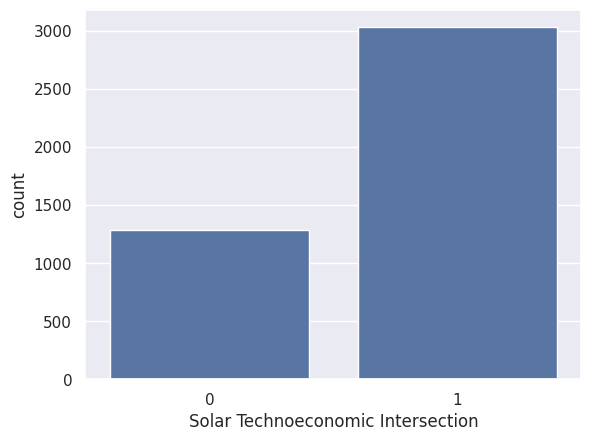

1   0.70
0   0.30
Name: Solar Technoeconomic Intersection, dtype: float64

We are dealing with imbalanced classes so that we need to apply oversampling or undersampling on the training data (we do not want to alter the test set). 
The over-sampling or under-sampling should happen after encoding and before scaling.


In [64]:
# Countplot of the target variable

sns.countplot(x="Solar Technoeconomic Intersection",data=pd.DataFrame(y_train)) 
#sns.countplot(x="Solar Technoeconomic Intersection",data=pd.DataFrame(y_test)) # XXX We should not gaze into the test data
plt.show()

print(y_train.value_counts(normalize = True))
print("\nWe are dealing with imbalanced classes so that we need to apply oversampling or undersampling on the training data (we do not want to alter the test set).", "\n"
      "The over-sampling or under-sampling should happen after encoding and before scaling.")
#print("\nWe have an uneven distribution of classes in the target. To circuvent this moderate class imbalance, we will choose oversampling because we don't want to create unreal class elements using SMOTE. We don't want to remove data using undersampling.")

/home/ubuntu/dec24_bds_solar_energy/solar_venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



Original class distribution: Counter({1: 3032, 0: 1285})
Resampled class distribution: Counter({0: 1285, 1: 1285})


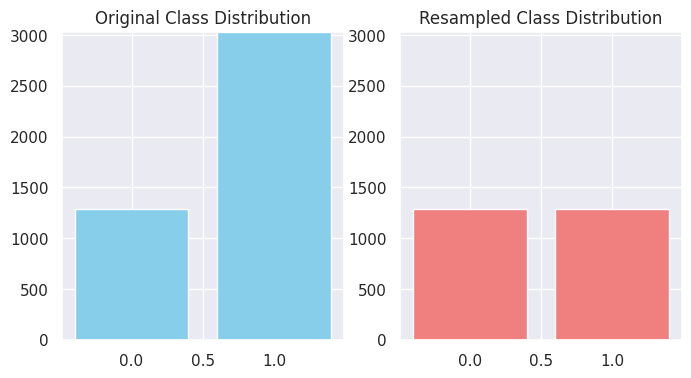

In [65]:
# Re-sampling method: ClusterCentroids 
# This technique reduces the size of the majority class without randomly removing data, ensuring that the representative centroids of the 
# majority class are kept, which can lead to more efficient training and better performance in some cases.
from imblearn.under_sampling import ClusterCentroids
from collections import Counter

def cluster_centroids_undersample(X_train, y_train, random_state=888):
    """
    Applies ClusterCentroids undersampling on the majority class.

    Args:
    - X_train: Features of the training dataset.
    - y_train: Target labels of the training dataset.
    - random_state: Random seed for reproducibility (default is 888).

    Returns:
    - X_train_resampled_cc: Resampled feature set.
    - y_train_resampled_cc: Resampled target labels.
    """
    # Define the ClusterCentroids undersampler
    cluster_centroids = ClusterCentroids(random_state=random_state) #, n_init=10)
    
    # Apply the undersampling
    X_train_resampled_cc, y_train_resampled_cc = cluster_centroids.fit_resample(X_train, y_train)
    
    # Print the class distribution before and after resampling
    print("Original class distribution:", Counter(y_train))
    print("Resampled class distribution:", Counter(y_train_resampled_cc))
    
    # Plotting class distribution before and after resampling
    plt.figure(figsize=(8, 4))

    # Get the maximum y-value for setting the same y-limits
    original_counts = Counter(y_train).values()
    resampled_counts = Counter(y_train_resampled_cc).values()
    max_y_value = max(max(original_counts), max(resampled_counts))

    # Original distribution
    plt.subplot(1, 2, 1)
    plt.bar(Counter(y_train).keys(), original_counts, color="skyblue")
    plt.title("Original Class Distribution")
    plt.ylim(0, max_y_value)  # Set y-axis limit

    # Resampled distribution
    plt.subplot(1, 2, 2)
    plt.bar(Counter(y_train_resampled_cc).keys(), resampled_counts, color="lightcoral")
    plt.title("Resampled Class Distribution")
    plt.ylim(0, max_y_value)  # Set y-axis limit

    # Return the resampled data for further processing or model training
    return X_train_resampled_cc, y_train_resampled_cc

X_train_resampled_cc, y_train_resampled_cc = cluster_centroids_undersample(X_train, y_train)
# We can now use the resampled data (X_train_resampled_cc, y_train_resampled_cc) for model training.


In [66]:
# I put your optional block here:
#
# "#optional block
# from imblearn.over_sampling import RandomOverSampler
# X_train_resampled, y_train_resampled = RandomOverSampler().fit_resample(X_train_norm, y_train)
# We can train the model either with (X_train_resampled, y_train_resampled) and (X_train_norm, y_train)"
#
# also into a function if you want to use it:
from imblearn.over_sampling import RandomOverSampler

def random_oversample(X_train, y_train):
    """
    Applies RandomOverSampler to balance the class distribution by over-sampling the minority class.

    Args:
    - X_train: Features of the training dataset.
    - y_train: Target labels of the training dataset.

    Returns:
    - X_train_resampled: Resampled feature set.
    - y_train_resampled: Resampled target labels.
    """
    # Apply RandomOverSampler
    X_train_resampled_rOs, y_train_resampled_rOs = RandomOverSampler().fit_resample(X_train, y_train)

    # Return the resampled data for further processing or model training
    return X_train_resampled_rOs, y_train_resampled_rOs


*Scaling*

In [67]:
display(X_train_resampled_cc.head()) # The re-sampled X_train is not scaled yet.

print("Following, we can see that there are columns with outliers (Acres, Distance to GTET 100, Distance to GTET 200, Distance to CAISO substation, Population Density) and columns", "\n", 
       "without. The latter are all originally categorical columns we do not need to scale. Therefore it is suitable to use a RobustScaler() for the columns with outliers.")
display(X_train_resampled_cc.describe())

,Acres,Urban or Rural,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Population Density,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
0,1.21,1,4.89,8.85,8.85,303.80,2.00,2.00,3.00,0,0
1,2718.79,1,6.80,6.80,6.14,41.80,3.00,2.00,2.00,0,0
2,0.19,1,6.57,6.57,6.57,103.30,3.00,2.00,2.00,0,0
3,81.13,1,3.10,3.10,3.10,103.30,2.00,0.00,1.00,0,0
4,3.80,1,2.21,12.95,2.21,103.30,1.00,3.00,0.00,0,0


Following, we can see that there are columns with outliers (Acres, Distance to GTET 100, Distance to GTET 200, Distance to CAISO substation, Population Density) and columns 
 without. The latter are all originally categorical columns we do not need to scale. Therefore it is suitable to use a RobustScaler() for the columns with outliers.


,Acres,Urban or Rural,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Population Density,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
count,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00
mean,46.43,0.51,5.74,10.87,7.15,652.00,1.72,1.78,1.64,0.13,0.19
std,256.92,0.50,5.95,9.54,5.69,1186.69,1.12,1.08,1.11,0.34,0.40
min,0.01,0.00,0.00,0.00,0.00,1.80,0.00,-0.00,-0.00,0.00,0.00
25%,1.29,0.00,1.70,4.18,3.07,103.30,1.00,1.00,1.00,0.00,0.00
50%,3.26,1.00,3.79,8.31,5.74,156.20,2.00,2.00,2.00,0.00,0.00
75%,9.07,1.00,7.75,14.15,9.61,735.80,3.00,3.00,3.00,0.00,0.00
max,7438.60,1.00,55.75,102.22,60.38,17179.20,3.00,3.00,3.00,1.00,1.00


In [68]:
# Robust Scaling with a function using a pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def scale_data(X_train, X_test):

    # In our dataset all numerical columns contain outliers (need scaling)
    numerical_columns_with_outliers = [
        "Acres", "Distance to GTET 100", "Distance to GTET 200", 
        "Distance to CAISO substation", "Population Density"
    ]

    # Other columns that do not need to be scaled (all categorical)
    columns_not_to_scale = [
        "Urban or Rural", "percentile_GTET100", "percentile_GTET200", "percentile_CAISO", "Parking", "Rooftop"
    ]

    # Define the column transformer for scaling (for a production setup all other transformation steps like encoding etc. would also fit here)
    preprocessor = ColumnTransformer(
        transformers=[ 
            ("num_with_outliers", RobustScaler(), numerical_columns_with_outliers), # Apply RobustScaler to numerical columns with outliers      
            ("columns_not_to_scale", "passthrough", columns_not_to_scale) # Keep categorical columns without scaling
        ]
    )

    # Creating a pipeline with preprocessing step
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

    # Fit the pipeline on the training data and transform X_train_resampled_cc
    X_train_scaled = pipeline.fit_transform(X_train_resampled_cc)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_columns_with_outliers + columns_not_to_scale)

    # Using the same preprocessor to transform the test set
    X_test_scaled = pipeline.transform(X_test)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_columns_with_outliers + columns_not_to_scale)

    # Check the scaled data shape
    print(f"Scaled X_train shape: {X_train_scaled.shape}")
    print(f"Scaled X_test shape: {X_test_scaled.shape}")

    pd.set_option('display.float_format', '{:.2f}'.format) # avoiding notation like 2.570000e+03 in the output
    display("X_train_scaled_df:", X_train_scaled_df.describe())  # We can see that the training data is now scaled
    display("X_test_scaled_df:", X_test_scaled_df.describe())  # We can see that the test data is now scaled, too and also has the same columns!
    
    return X_train_scaled_df, X_test_scaled_df

X_train_scaled_df, X_test_scaled_df = scale_data(X_train_resampled_cc, X_test)

Scaled X_train shape: (2570, 11)
Scaled X_test shape: (1080, 11)


'X_train_scaled_df:'

,Acres,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Population Density,Urban or Rural,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
count,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00,2570.00
mean,5.55,0.32,0.26,0.22,0.78,0.51,1.72,1.78,1.64,0.13,0.19
std,33.03,0.98,0.96,0.87,1.88,0.50,1.12,1.08,1.11,0.34,0.40
min,-0.42,-0.63,-0.83,-0.88,-0.24,0.00,0.00,-0.00,-0.00,0.00,0.00
25%,-0.25,-0.35,-0.41,-0.41,-0.08,0.00,1.00,1.00,1.00,0.00,0.00
50%,0.00,-0.00,-0.00,0.00,0.00,1.00,2.00,2.00,2.00,0.00,0.00
75%,0.75,0.65,0.59,0.59,0.92,1.00,3.00,3.00,3.00,0.00,0.00
max,955.92,8.60,9.42,8.35,26.91,1.00,3.00,3.00,3.00,1.00,1.00


'X_test_scaled_df:'

,Acres,Distance to GTET 100,Distance to GTET 200,Distance to CAISO substation,Population Density,Urban or Rural,percentile_GTET100,percentile_GTET200,percentile_CAISO,Parking,Rooftop
count,1080.00,1080.00,1080.00,1080.00,1080.00,1080.00,1080.00,1080.00,1080.00,1080.00,1080.00
mean,2.88,0.19,0.07,0.11,1.20,0.32,1.48,1.45,1.50,0.26,0.35
std,14.89,0.96,0.96,0.81,1.78,0.47,1.11,1.13,1.11,0.44,0.48
min,-0.42,-0.63,-0.83,-0.87,-0.24,0.00,0.00,0.00,0.00,0.00,0.00
25%,-0.30,-0.40,-0.54,-0.47,-0.08,0.00,0.00,0.00,0.00,0.00,0.00
50%,-0.14,-0.19,-0.25,-0.09,0.30,0.00,1.00,1.00,2.00,0.00,0.00
75%,0.18,0.38,0.36,0.43,2.08,1.00,2.00,2.00,2.00,1.00,1.00
max,266.93,5.53,6.29,5.78,26.91,1.00,3.00,3.00,3.00,1.00,1.00


**Modeling?**

In [ ]:
# It could make sense to save the all data frames (X_train_scaled, X_test_scaled, y_train_resampled, y_test) into .csv so far
# (e.g. data/processed/training_data_clean.csv and .../test_data_clean.csv) in order to switch to a new notebook [1.0-Solar_Energy-Modeling.ipynb] where we can do all the modeling 
# because this notebook is very long so far...

In [71]:
# Only test-wise I used a baseline model (RandomForestClassifier) to see if the pre-processing was okay (so this notebook cell is just a test):
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Instantiating the model (e.g., RandomForestClassifier) and train the model on the scaled training data (y_train does not need to be scaled since it is binary)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled_df, y_train_resampled_cc)

# Create predictions
y_pred = model.predict(X_test_scaled_df)

# Evaluate model performance using a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       322
           1       0.95      0.95      0.95       758

    accuracy                           0.93      1080
   macro avg       0.91      0.91      0.91      1080
weighted avg       0.93      0.93      0.93      1080

